# 02 — Modeling: K-Means vs DBSCAN
Tuning hyperparameter (grid search), evaluasi (Silhouette, Davies-Bouldin, Inertia), dan pemilihan model final.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.append(str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
FIG = ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", None)

In [2]:
from sklearn.preprocessing import StandardScaler
from utils import FEATURES, RANDOM_STATE
from train_model import kmeans_grid_search, dbscan_grid_search, label_clusters

df = pd.read_csv(ROOT / "data" / "processed" / "dataset_pangan_terintegrasi.csv")
X_raw = df[FEATURES].values
scaler = StandardScaler().fit(X_raw)
X = scaler.transform(X_raw)
print(f"Fitur clustering: {FEATURES} | shape: {X.shape}")

Fitur clustering: ['KV_2022', 'KV_2023', 'KV_2024', 'CPPD_Ton'] | shape: (25, 4)


## 1. Grid Search K-Means
Grid: K ∈ {2..8} × init ∈ {k-means++, random} × n_init ∈ {10, 20, 30}, max_iter=300, random_state=42 → 42 kombinasi.

In [3]:
kmeans_grid = kmeans_grid_search(X)
kmeans_grid.to_csv(ROOT / "reports" / "kmeans_grid.csv", index=False)
kmeans_grid.sort_values("silhouette", ascending=False).head(10)

,K,init,n_init,inertia,silhouette,davies_bouldin
6,3,k-means++,10,43.339980,0.405610,0.763959
7,3,k-means++,20,43.339980,0.405610,0.763959
8,3,k-means++,30,43.339980,0.405610,0.763959
9,3,random,10,43.339980,0.405610,0.763959
10,3,random,20,43.339980,0.405610,0.763959
11,3,random,30,43.339980,0.405610,0.763959
15,4,random,10,32.532927,0.395107,0.581070
12,4,k-means++,10,32.532927,0.395107,0.581070
17,4,random,30,32.532927,0.395107,0.581070
16,4,random,20,32.532927,0.395107,0.581070


## 2. Grid Search DBSCAN (baseline pembanding)
Grid: eps ∈ {0.3, 0.5, 0.7, 1.0, 1.3, 1.6} × min_samples ∈ {2..5}. Silhouette dihitung **hanya pada non-noise points**.

In [4]:
dbscan_grid = dbscan_grid_search(X)
dbscan_grid.to_csv(ROOT / "reports" / "dbscan_grid.csv", index=False)
dbscan_grid.sort_values("silhouette_non_noise", ascending=False).head(10)

,eps,min_samples,n_clusters,n_noise,noise_pct,silhouette_non_noise,davies_bouldin_non_noise
12,1.0,2,2,11,44.0,0.635503,0.447514
13,1.0,3,2,11,44.0,0.635503,0.447514
4,0.5,2,3,17,68.0,0.488541,0.526972
8,0.7,2,4,12,48.0,0.345161,0.713087
0,0.3,2,0,25,100.0,NaN,NaN
1,0.3,3,0,25,100.0,NaN,NaN
2,0.3,4,0,25,100.0,NaN,NaN
3,0.3,5,0,25,100.0,NaN,NaN
5,0.5,3,1,21,84.0,NaN,NaN
6,0.5,4,0,25,100.0,NaN,NaN


## 3. Penentuan K Optimal — Elbow & Silhouette

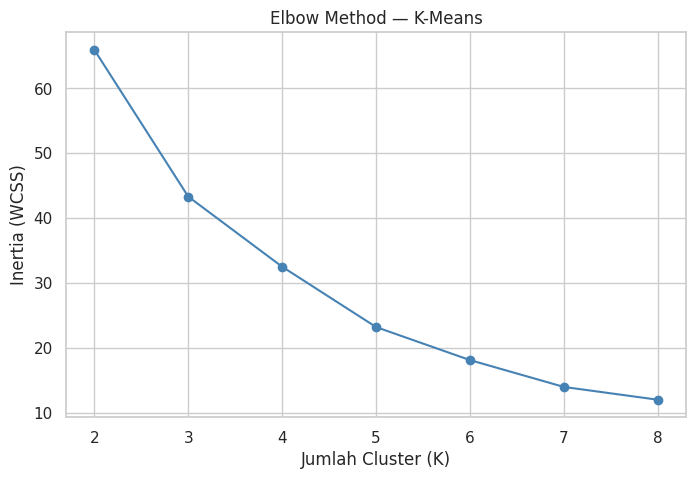

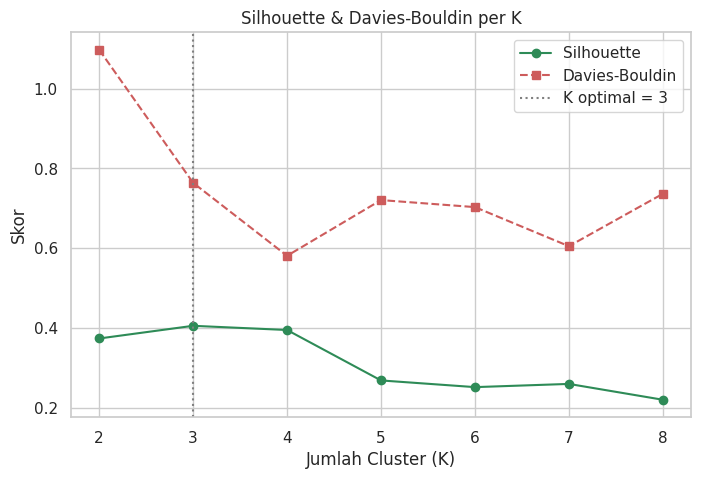

In [5]:
from evaluate_model import plot_elbow, plot_silhouette_per_k
plot_elbow(kmeans_grid); plt.show()
plot_silhouette_per_k(kmeans_grid); plt.show()

**Analisis pemilihan K (diskusi overfitting/underfitting ala unsupervised):**
- **K=2** terlalu general (underfit): hanya memisahkan outlier CPPD dari sisanya, tidak menangkap gradasi stabilitas.
- **K=3** silhouette tertinggi (~0.40) dan DBI terendah — struktur paling seimbang.
- **K≥5** menghasilkan cluster beranggota 1–2 provinsi yang tidak bermakna kebijakan (analog overfit terhadap noise).

Silhouette final (~0.40) di bawah target proposal 0.5 — wajar untuk data sosial-ekonomi yang batas antar kelompoknya tidak tegas; trade-off ini dibahas vs DBSCAN di bawah.

## 4. Model Final K-Means (K=3) + Labeling Segmen

In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

best = kmeans_grid.sort_values("silhouette", ascending=False).iloc[0]
K = int(best["K"])
kmeans = KMeans(n_clusters=K, init=best["init"], n_init=int(best["n_init"]),
                max_iter=300, random_state=RANDOM_STATE).fit(X)
df["Cluster"] = kmeans.labels_

centroids = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=FEATURES)
label_names = label_clusters(df, centroids)
df["Segmen"] = df["Cluster"].map(label_names)

sil = silhouette_score(X, kmeans.labels_)
dbi = davies_bouldin_score(X, kmeans.labels_)
print(f"K={K} | Silhouette={sil:.4f} | Davies-Bouldin={dbi:.4f} | Inertia={kmeans.inertia_:.2f}")
for cid, name in sorted(label_names.items()):
    print(f"  Cluster {cid}: {name} ({(df['Cluster']==cid).sum()} provinsi)")

K=3 | Silhouette=0.4056 | Davies-Bouldin=0.7640 | Inertia=43.34
  Cluster 0: Zona Rentan Fluktuatif (7 provinsi)
  Cluster 1: Zona Mandiri & Stabil (17 provinsi)
  Cluster 2: Zona Hub Logistik (Surplus CPPD) (1 provinsi)


## 5. Visualisasi Hasil — PCA 2D & Profil Centroid

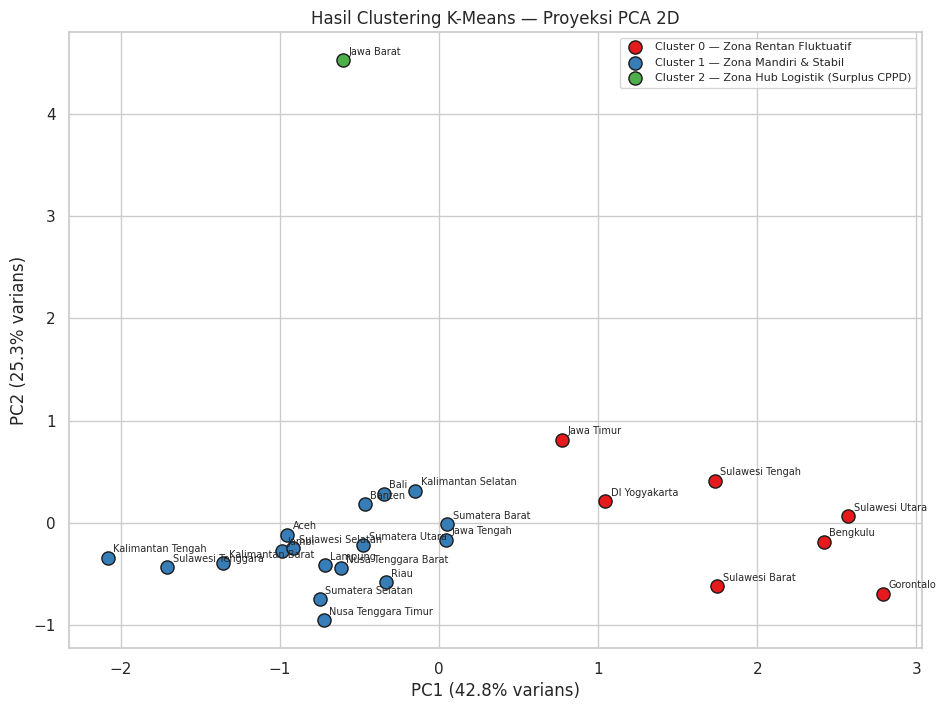

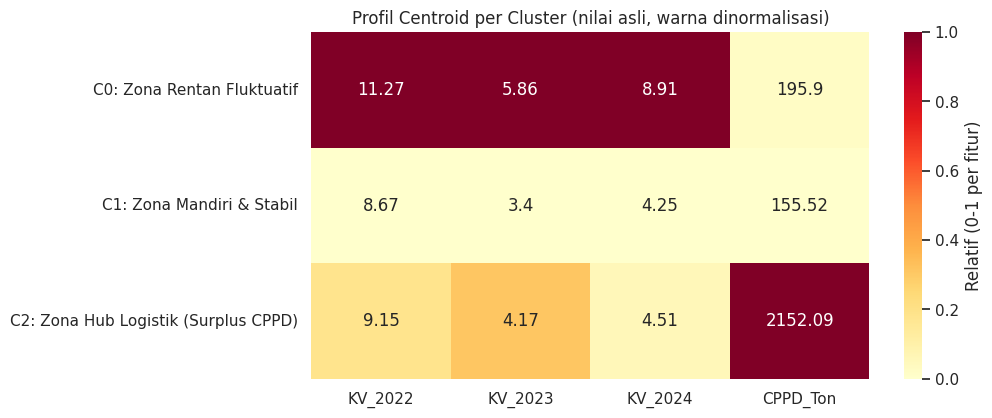

In [7]:
import joblib
joblib.dump(kmeans, ROOT / "models" / "kmeans_model.pkl")
joblib.dump(scaler, ROOT / "models" / "scaler.pkl")
meta = {"features": FEATURES, "label_names": label_names}
joblib.dump(meta, ROOT / "models" / "meta.pkl")
df.to_csv(ROOT / "data" / "processed" / "hasil_clustering.csv", index=False)

from evaluate_model import plot_pca_clusters, plot_centroid_heatmap
plot_pca_clusters(df, scaler); plt.show()
plot_centroid_heatmap(kmeans, scaler, meta); plt.show()

**Interpretasi fitur via profil centroid:** SHAP/LIME tidak berlaku untuk unsupervised learning (tidak ada target yang diprediksi), sehingga interpretasi fitur dilakukan melalui perbandingan nilai centroid antar cluster pada skala asli — terlihat jelas fitur mana yang membedakan tiap segmen (CPPD ekstrem memisahkan hub; level KV memisahkan stabil vs rentan).

## 6. Perbandingan Final: K-Means vs DBSCAN

In [8]:
best_db = dbscan_grid.dropna(subset=["silhouette_non_noise"]).sort_values(
    "silhouette_non_noise", ascending=False).iloc[0]
comp = pd.DataFrame({
    "Model": ["K-Means (K=3)", f"DBSCAN (eps={best_db['eps']}, min_samples={int(best_db['min_samples'])})"],
    "Silhouette": [round(sil, 4), round(best_db["silhouette_non_noise"], 4)],
    "Davies-Bouldin": [round(dbi, 4), round(best_db["davies_bouldin_non_noise"], 4)],
    "Cakupan provinsi": ["100%", f"{100 - best_db['noise_pct']:.0f}% (noise {best_db['noise_pct']}%)"],
})
comp

,Model,Silhouette,Davies-Bouldin,Cakupan provinsi
0,K-Means (K=3),0.4056,0.7640,100%
1,"DBSCAN (eps=1.0, min_samples=2)",0.6355,0.4475,56% (noise 44.0%)


**Keputusan: K-Means dipilih sebagai model final.** DBSCAN mencapai silhouette lebih tinggi, tetapi hanya dengan membuang ~44% provinsi sebagai noise. Untuk pemetaan kebijakan pangan, **setiap provinsi wajib mendapat segmen** — provinsi "noise" justru sering yang paling butuh intervensi. Silhouette DBSCAN yang tinggi adalah artefak dari mengevaluasi subset data yang mudah saja, bukan kualitas segmentasi populasi penuh.